In [25]:
import numpy as np
import pandas as pd
import yfinance as yf

In [26]:
# 1) 离线 ticker 列表（约 200 只）
# 说明：由于当前环境无法访问 Wikipedia，这里用一份“示例用”的离线列表来近似回测 January effect。
# 这不是严格的“历史 S&P600 成分股”（存在幸存者偏差），但足够演示 Chan 的十分位多空逻辑。

# 你也可以自行替换为你想测试的股票池（越多越接近横截面效应）
tickers = [
    "AA", "AAL", "AAP", "AAPL", "ABNB", "ABT", "ACGL", "ACN", "ADBE", "ADI",
    "ADM", "ADP", "ADSK", "AEE", "AEM", "AFL", "AIG", "AJG", "AKAM", "ALB",
    "ALGN", "ALL", "ALLE", "AMAT", "AMD", "AMGN", "AMKR", "AMP", "AMT", "AMZN",
    "ANET", "ANSS", "AON", "AOS", "APA", "APD", "APH", "ARE", "ATO", "AVB",
    "AVGO", "AVY", "AXP", "AZO", "BA", "BAC", "BALL", "BAX", "BBY", "BDX",
    "BEN", "BF-B", "BIIB", "BK", "BKNG", "BKR", "BLK", "BMY", "BR", "BRO",
    "BSX", "BWA", "BXP", "C", "CAG", "CAH", "CARR", "CAT", "CB", "CBOE",
    "CBRE", "CCI", "CCL", "CDNS", "CF", "CFG", "CHD", "CHRW", "CI", "CINF",
    "CL", "CLX", "CMA", "CMCSA", "CME", "CMG", "CMI", "CMS", "CNP", "COF",
    "COO", "COP", "COST", "CPB", "CPRT", "CPT", "CRL", "CRM", "CSCO", "CSX",
    "CTAS", "CTRA", "CTSH", "CVS", "CVX", "D", "DAL", "DD", "DE", "DG",
    "DHI", "DHR", "DIS", "DLR", "DLTR", "DOV", "DOW", "DPZ", "DRI", "DTE",
    "DUK", "DXCM", "EA", "EBAY", "ECL", "ED", "EFX", "EG", "EIX", "EL",
    "EMN", "EMR", "EOG", "EQIX", "EQR", "ES", "ESS", "ETN", "ETR", "EW",
    "EXC", "EXPD", "EXPE", "F", "FANG", "FAST", "FCX", "FDX", "FE", "FFIV",
    "FIS", "FISV", "FITB", "FMC", "FOXA", "FRC", "FRT", "FTNT", "GD", "GE",
    "GILD", "GIS", "GL", "GLW", "GM", "GNRC", "GOOG", "GOOGL", "GPC", "GPN",
    "GPS", "GRMN", "GS", "GWW", "HAL", "HAS", "HBAN", "HCA", "HD", "HES",
    "HIG", "HOLX", "HON", "HPQ", "HRL", "HSIC", "HST", "HSY", "HUM", "IBM",
    "ICE", "IDXX", "IEX", "IFF", "ILMN", "INCY", "INTC", "INTU", "INVH", "IP",
    "IPG", "IQV", "IR", "IRM", "ISRG", "IT", "ITW", "IVZ", "J", "JBHT",
    "JCI", "JKHY", "JNJ", "JNPR", "JPM", "K", "KEY", "KHC", "KIM", "KLAC",
    "KMB", "KMI", "KMX", "KO", "KR", "L", "LDOS", "LEN", "LH", "LHX",
    "LIN", "LKQ", "LLY", "LMT", "LNT", "LOW", "LRCX", "LUMN", "LUV", "LVS",
    "MA", "MAA", "MAR", "MAS", "MCD", "MCHP", "MCK", "MCO", "MDLZ", "MDT",
    "MET", "MGM", "MHK", "MKC", "MKTX", "MLM", "MMC", "MMM", "MNST", "MO",
]

# yfinance 对 BRK.B 这类用 '-' 表示（本列表里已经用 BF-B 形式示例）
tickers = [t.replace(".", "-") for t in tickers]

print("offline tickers:", len(tickers))

offline tickers: 260


In [27]:
# 如果 yfinance 下载出现 rate limit error，修改代理设置，并运行以下代码
# 详情见 https://blog.csdn.net/m0_50837851/article/details/146198595

import os
proxy = 'http://127.0.0.1:7897'	# 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy 
os.environ['HTTPS_PROXY'] = proxy 

In [44]:
# 2) 用 yfinance 下载（注意：数量多，可能需要分批）
start = "2004-01-01"
end   = "2008-02-28"   # 对齐书里例子（你也可以改更长）
data = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=True,
    group_by="ticker",
    threads=True,
    progress=True,
)

# 3) 整理成 cl（行=日期，列=股票，值=收盘价）
# yfinance 多标的返回结构可能不同，这里做一个稳妥处理
if isinstance(data.columns, pd.MultiIndex):
    cl = data.xs("Close", axis=1, level=1)
else:
    # 只有一个 ticker 时
    cl = data[["Close"]].rename(columns={"Close": tickers[0]})

cl = cl.sort_index()
cl = cl.dropna(axis=1, how='all')
print("cl shape:", cl.shape)
cl.head()

[*********************100%***********************]  260 of 260 completed

25 Failed downloads:
['HCA', 'GM', 'KMI', 'CARR', 'ANET', 'AVGO', 'IR', 'DG', 'INVH', 'ABNB', 'CFG', 'FOXA', 'ALLE', 'KHC', 'FANG', 'DOW', 'IQV', 'GNRC', 'FTNT', 'CBOE']: YFPricesMissingError('possibly delisted; no price data found  (1d 2004-01-01 -> 2008-02-28) (Yahoo error = "Data doesn\'t exist for startDate = 1072933200, endDate = 1204174800")')
['GPS', 'FRC', 'JNPR', 'HES', 'ANSS']: YFTzMissingError('possibly delisted; no timezone found')


cl shape: (1045, 235)


Ticker,MA,CPRT,HOLX,GIS,ESS,ED,DIS,ALB,EXPD,HIG,...,MO,CVX,COST,DHI,HSY,HD,JKHY,GL,AFL,IRM
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-02,NaN,1.050000,4.4100,11.089277,29.993450,16.769623,18.609777,10.939998,14.556748,36.726089,...,3.455994,18.702200,24.264616,15.557328,22.681957,20.844936,15.650005,16.447611,11.089179,6.398540
2004-01-05,NaN,1.045000,4.4400,11.271589,29.624035,16.660378,18.979305,11.012331,15.002844,37.193108,...,3.430065,19.063665,24.151045,15.220505,22.788658,20.850899,15.854833,16.563404,10.735927,6.455656
2004-01-06,NaN,1.072500,4.5000,11.209996,29.455675,16.652576,19.026470,11.008713,14.908933,37.081032,...,3.404139,18.959143,24.424948,15.504917,22.868662,21.077074,15.551397,16.519979,10.735927,7.175308
2004-01-07,NaN,1.078125,4.5875,11.175508,29.357487,16.738413,19.340963,11.026797,14.799358,37.952812,...,3.359239,18.717447,24.772360,15.456283,22.785700,21.368746,15.475527,16.501883,10.874156,6.853829
2004-01-08,NaN,1.096875,4.5275,11.265982,29.334089,16.711105,19.623999,11.019561,14.721095,38.662663,...,3.357973,18.737055,24.892609,14.876201,22.548607,21.190166,15.316218,16.501883,10.917159,6.974587


In [45]:
def assert_(pred, msg=""):
    if not bool(pred):
        raise AssertionError(f"assertion violated: {msg}")


def fwdshift(day: int, x: np.ndarray) -> np.ndarray:
    assert_(day >= 0, "day must be >= 0")
    y = np.empty_like(x, dtype=float)
    y[:-day or None] = x[day:]
    if day > 0:
        y[-day:] = np.nan
    return y


def smartmean(x: np.ndarray) -> float:
    return float(np.nanmean(x))


In [46]:
onewaytcost=0.0005
"""
cl: DataFrame, index=DatetimeIndex (trading days), columns=tickers, values=close prices
Implements Chan Example 7.6 logic:
    - For each year y:
    sort stocks by prior calendar year's return ascending
    long lowest decile, short highest decile
    hold from last trading day of Dec to last trading day of Jan
"""
assert_(isinstance(cl.index, pd.DatetimeIndex), "cl.index must be a DatetimeIndex")
cl = cl.sort_index()

dates = cl.index
years = dates.year.to_numpy()
months = dates.month.to_numpy()

nextyear = fwdshift(1, years.astype(float))
nextmonth = fwdshift(1, months.astype(float))

In [47]:
print("nextyear\n", nextyear)
print("nextmonth\n", nextmonth)

nextyear
 [2004. 2004. 2004. ... 2008. 2008.   nan]
nextmonth
 [ 1.  1.  1. ...  2.  2. nan]


In [48]:
# last trading day of Dec: month==12 and next month == 1
lastdayofDec = np.where((months == 12) & (nextmonth == 1))[0]

# last trading day of Jan: month==1 and next month == 2
lastdayofJan = np.where((months == 1) & (nextmonth == 2))[0]

In [49]:
print("lastdayofDec\n", lastdayofDec)
print("lastdayofJan\n", lastdayofJan)

lastdayofDec
 [ 251  503  754 1005]
lastdayofJan
 [  19  271  523  774 1026]


In [50]:
# MATLAB: lastdayofDec starts in 2004 so remove 2004 from lastdayofJan
# Here: align lengths so that each Jan follows its Dec
# (drop leading Jan(s) that come before the first Dec in lastdayofDec)
if len(lastdayofDec) > 0:
    lastdayofJan = lastdayofJan[dates[lastdayofJan] > dates[lastdayofDec[0]]]

assert_(np.all(dates[lastdayofJan] > dates[lastdayofDec[: len(lastdayofJan)]]),
        "Each lastdayofJan should be after lastdayofDec")

In [51]:
print("lastdayofDec\n", lastdayofDec)
print("lastdayofJan\n", lastdayofJan)

lastdayofDec
 [ 251  503  754 1005]
lastdayofJan
 [ 271  523  774 1026]


In [52]:
# End-of-year indices: year != nextyear (excluding last row)
eoy = np.where(years != nextyear)[0]
if len(eoy) > 0 and eoy[-1] == len(dates) - 1:
    eoy = eoy[:-1]

# Ensure eoy matches lastdayofDec (as MATLAB assert)
# (depending on data availability, you may want to relax this)
assert_(len(eoy) == len(lastdayofDec), "eoy and lastdayofDec length mismatch")
assert_(np.all(dates[eoy] == dates[lastdayofDec]), "eoy dates != lastdayofDec dates")

In [53]:
eoy

array([ 251,  503,  754, 1005])

In [54]:
clv = cl.to_numpy(dtype=float)
cl

Ticker,MA,CPRT,HOLX,GIS,ESS,ED,DIS,ALB,EXPD,HIG,...,MO,CVX,COST,DHI,HSY,HD,JKHY,GL,AFL,IRM
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-02,NaN,1.050000,4.410000,11.089277,29.993450,16.769623,18.609777,10.939998,14.556748,36.726089,...,3.455994,18.702200,24.264616,15.557328,22.681957,20.844936,15.650005,16.447611,11.089179,6.398540
2004-01-05,NaN,1.045000,4.440000,11.271589,29.624035,16.660378,18.979305,11.012331,15.002844,37.193108,...,3.430065,19.063665,24.151045,15.220505,22.788658,20.850899,15.854833,16.563404,10.735927,6.455656
2004-01-06,NaN,1.072500,4.500000,11.209996,29.455675,16.652576,19.026470,11.008713,14.908933,37.081032,...,3.404139,18.959143,24.424948,15.504917,22.868662,21.077074,15.551397,16.519979,10.735927,7.175308
2004-01-07,NaN,1.078125,4.587500,11.175508,29.357487,16.738413,19.340963,11.026797,14.799358,37.952812,...,3.359239,18.717447,24.772360,15.456283,22.785700,21.368746,15.475527,16.501883,10.874156,6.853829
2004-01-08,NaN,1.096875,4.527500,11.265982,29.334089,16.711105,19.623999,11.019561,14.721095,38.662663,...,3.357973,18.737055,24.892609,14.876201,22.548607,21.190166,15.316218,16.501883,10.917159,6.974587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008-02-21,18.668497,2.417500,29.780001,15.374757,57.468479,20.186914,26.747423,30.109087,32.406620,49.080364,...,7.398776,42.067299,45.107304,12.469266,23.632851,17.355364,19.330276,22.833326,20.390207,12.237761
2008-02-22,18.577194,2.429375,29.365000,15.574578,59.258453,20.399921,26.996082,29.303610,32.614315,49.871658,...,7.419948,42.384846,45.836292,12.387872,23.774828,17.596144,19.172075,23.072607,20.432240,12.109249
2008-02-25,18.117971,2.471875,29.905001,15.757967,59.620766,20.438643,27.261322,30.845510,32.933815,49.891788,...,7.486484,43.258156,45.565525,12.615771,24.465359,18.261471,19.203712,23.214689,20.703806,12.127611


In [55]:
# annual returns between consecutive EOY dates
annret = (clv[eoy[1:], :] - clv[eoy[:-1], :]) / clv[eoy[:-1], :]

print(annret.shape)

(3, 235)


In [56]:
# January returns: from last day of Dec to last day of Jan (same 'year index' as annret rows)
# MATLAB uses lastdayofDec(2:end) and lastdayofJan(2:end) to align with prior-year annret
# Align them by taking the same number of rows as annret
dec_idx = lastdayofDec[1: 1 + annret.shape[0]]
jan_idx = lastdayofJan[1: 1 + annret.shape[0]]
janret = (clv[jan_idx, :] - clv[dec_idx, :]) / clv[dec_idx, :]

print(janret.shape)

(3, 235)


In [57]:
results = []
for y in range(annret.shape[0]):
    hasData = np.where(np.isfinite(annret[y, :]))[0]
    if len(hasData) == 0:
        continue

    sortidx = np.argsort(annret[y, hasData])  # ascending
    topN = int(round(len(hasData) / 10))
    if topN < 1:
        continue

    losers = hasData[sortidx[:topN]]
    winners = hasData[sortidx[-topN:]]

    portRet = (smartmean(janret[y, losers]) - smartmean(janret[y, winners])) / 2.0 - 2.0 * onewaytcost

    holding_date = dates[dec_idx[y]].strftime("%Y%m%d")
    print(f"Last holding date {holding_date}: Portfolio return={portRet:7.4f}")
    results.append((dates[dec_idx[y]], portRet))

    results_series = pd.Series({d: r for d, r in results}).sort_index()

Last holding date 20051230: Portfolio return=-0.0510
Last holding date 20061229: Portfolio return=-0.0284
Last holding date 20071231: Portfolio return= 0.0814


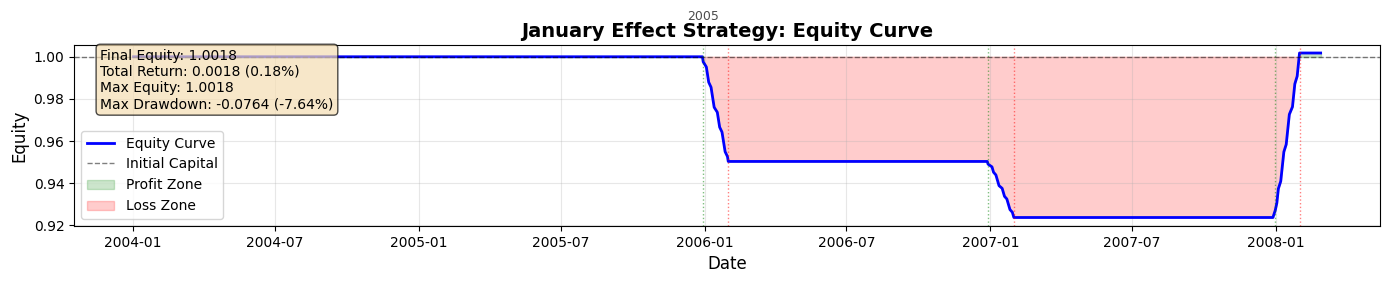


=== Equity Curve Statistics ===
Initial Capital: 1.0000
Final Equity: 1.0018
Total Return: 0.0018 (0.18%)
Max Equity: 1.0018
Max Drawdown: -0.0764 (-7.64%)
Number of trading days: 1045
Number of holding periods: 3


In [61]:
import matplotlib.pyplot as plt
# 构建每日的 equity curve
# 策略：每年 12 月最后一个交易日建仓，持有到次年 1 月最后一个交易日，其他时间空仓

# 确保 results_series 存在
if 'results_series' not in locals():
    results = []
    for y in range(annret.shape[0]):
        hasData = np.where(np.isfinite(annret[y, :]))[0]
        if len(hasData) == 0:
            continue
        sortidx = np.argsort(annret[y, hasData])
        topN = int(round(len(hasData) / 10))
        if topN < 1:
            continue
        losers = hasData[sortidx[:topN]]
        winners = hasData[sortidx[-topN:]]
        portRet = (smartmean(janret[y, losers]) - smartmean(janret[y, winners])) / 2.0 - 2.0 * onewaytcost
        holding_date = dates[dec_idx[y]]
        results.append((holding_date, portRet))
    results_series = pd.Series({d: r for d, r in results}).sort_index()

# 创建每日收益序列
daily_ret = pd.Series(0.0, index=dates)

# 为每年的 1 月持仓期间分配收益
for y in range(annret.shape[0]):
    dec_date_idx = dec_idx[y]
    jan_date_idx = jan_idx[y]
    
    # 计算持仓天数
    holding_days = jan_date_idx - dec_date_idx + 1
    
    # 将年度收益平均分配到每一天（简单线性分配）
    # 或者更准确：只在最后一天实现收益（这里用平均分配作为近似）
    if holding_days > 0:
        daily_ret_per_day = results_series.iloc[y] / holding_days
        daily_ret.iloc[dec_date_idx:jan_date_idx+1] = daily_ret_per_day

# 计算累计 equity curve
equity_curve = (1 + daily_ret).cumprod()

# 画图
plt.figure(figsize=(14, 3))
plt.plot(equity_curve.index, equity_curve.values, linewidth=2, color='blue', label='Equity Curve')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')

# 标记每年的建仓和平仓点
for y in range(annret.shape[0]):
    dec_date = dates[dec_idx[y]]
    jan_date = dates[jan_idx[y]]
    plt.axvline(dec_date, color='green', linestyle=':', alpha=0.5, linewidth=1)
    plt.axvline(jan_date, color='red', linestyle=':', alpha=0.5, linewidth=1)
    # 标注年份
    if y == 0:
        plt.text(dec_date, equity_curve.loc[dec_date] * 1.02, f'{dec_date.year}', 
                ha='center', fontsize=9, alpha=0.7)

plt.fill_between(equity_curve.index, 1.0, equity_curve.values, 
                 where=(equity_curve.values >= 1.0), alpha=0.2, color='green', label='Profit Zone')
plt.fill_between(equity_curve.index, 1.0, equity_curve.values, 
                 where=(equity_curve.values < 1.0), alpha=0.2, color='red', label='Loss Zone')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Equity', fontsize=12)
plt.title('January Effect Strategy: Equity Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# 添加统计信息
final_equity = equity_curve.iloc[-1]
total_return = final_equity - 1.0
max_equity = equity_curve.max()
max_drawdown = (equity_curve / equity_curve.expanding().max() - 1).min()

stats_text = f"Final Equity: {final_equity:.4f}\nTotal Return: {total_return:.4f} ({total_return*100:.2f}%)\nMax Equity: {max_equity:.4f}\nMax Drawdown: {max_drawdown:.4f} ({max_drawdown*100:.2f}%)"
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\n=== Equity Curve Statistics ===")
print(f"Initial Capital: 1.0000")
print(f"Final Equity: {final_equity:.4f}")
print(f"Total Return: {total_return:.4f} ({total_return*100:.2f}%)")
print(f"Max Equity: {max_equity:.4f}")
print(f"Max Drawdown: {max_drawdown:.4f} ({max_drawdown*100:.2f}%)")
print(f"Number of trading days: {len(equity_curve)}")
print(f"Number of holding periods: {len(results_series)}")
